In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.
    aln.params.sigmai_ext = 0.
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.
    
def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int

In [23]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

max delay =  0


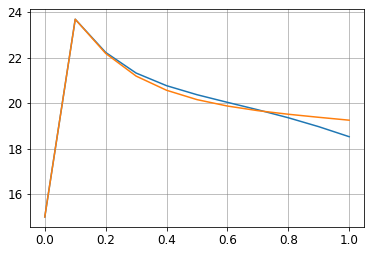

In [24]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars
    
state_vars = aln.state_vars
init_vars = aln.init_vars

In [25]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-16

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [45]:
#setparams()

dur = 1.
aln.params.duration = dur

aln.params.sigmae_ext = 2.
aln.params.sigmai_ext = 2.
    
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

target = aln.getZeroTarget()

c_range = np.arange(0., 5., 1.)

control1 = aln.getZeroControl()
control1[0,1,8] += 1.
control2 = aln.getZeroControl()

max_cntrl = 50. * 5.
start_step = 1e3
cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])
max_it = 25

improve = np.zeros( (len(c_range), len(c_range)) )
diff = np.zeros( (len(c_range), len(c_range)) )

for s_exc in range(len(c_range)):
    for s_inh in range(len(c_range)):
        print("---------------------------------------")
        print(s_exc, s_inh)
        aln.params.ext_exc_current = c_range[s_exc]
        aln.params.ext_inh_current = c_range[s_inh]
        set_init(initvars)

        aln.run(control=control1)

        target[:,0,:] = aln.state["rates_exc"][0,:]
        target[:,1,:] = aln.state["rates_inh"][0,:]
        
        set_init(initvars)

        A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
            u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            variables_ = [0])
        
        improve[s_exc, s_inh] = A1_cost[-1]/A1_cost[0]
        diff[s_exc, s_inh] = diff_control(A1_bestControl-control1)

set cost params
---------------------------------------
0 0
True 0
RUN  0 , total integrated cost =  1.8403980588579902e-05
RUN  1 , total integrated cost =  9.354944719266973e-06
RUN  2 , total integrated cost =  9.051478212536604e-06
RUN  3 , total integrated cost =  8.74486507373542e-06
RUN  4 , total integrated cost =  8.502442694719905e-06
RUN  5 , total integrated cost =  8.280580458150557e-06
RUN  6 , total integrated cost =  8.124941734709722e-06
RUN  7 , total integrated cost =  7.965078837436217e-06
RUN  8 , total integrated cost =  7.77299177122609e-06
RUN  9 , total integrated cost =  7.581003893097354e-06
RUN  10 , total integrated cost =  7.43886468990438e-06
RUN  11 , total integrated cost =  7.299378211137259e-06
RUN  12 , total integrated cost =  7.123999232870967e-06
RUN  13 , total integrated cost =  6.9562553762875276e-06
RUN  14 , total integrated cost =  6.827338506709894e-06
RUN  15 , total integrated cost =  6.704626004134542e-06
RUN  16 , total integrated cost 

RUN  17 , total integrated cost =  4.33460531353964e-07
RUN  18 , total integrated cost =  4.2247414207745967e-07
RUN  19 , total integrated cost =  4.1188157298563606e-07
RUN  20 , total integrated cost =  4.016713279849388e-07
RUN  21 , total integrated cost =  3.9148416274168933e-07
RUN  22 , total integrated cost =  3.829342717958681e-07
RUN  23 , total integrated cost =  3.750445924959809e-07
RUN  24 , total integrated cost =  3.660455894112339e-07
RUN  25 , total integrated cost =  3.5689650136634946e-07
Improved over  25  iterations by  74.87856275800246  percent.
max value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([2], dtype=int64)) -8.293831632790141e-05
--------------------------

RUN  5 , total integrated cost =  1.5003952281523485e-07
RUN  6 , total integrated cost =  1.4296911746811426e-07
RUN  7 , total integrated cost =  1.3591839891965782e-07
RUN  8 , total integrated cost =  1.3003200684086925e-07
RUN  9 , total integrated cost =  1.24972398520828e-07
RUN  10 , total integrated cost =  1.2090321444918146e-07
RUN  11 , total integrated cost =  1.1724932928465773e-07
RUN  12 , total integrated cost =  1.1284361685831538e-07
RUN  13 , total integrated cost =  1.0890597375742486e-07
RUN  14 , total integrated cost =  1.0584260407471235e-07
RUN  15 , total integrated cost =  1.0300432816858468e-07
RUN  16 , total integrated cost =  9.969166430167506e-08
RUN  17 , total integrated cost =  9.661979673147856e-08
RUN  18 , total integrated cost =  9.430122721014522e-08
RUN  19 , total integrated cost =  9.209011985606743e-08
RUN  20 , total integrated cost =  8.958305200595924e-08
RUN  21 , total integrated cost =  8.718017261680676e-08
RUN  22 , total integrated 

RUN  22 , total integrated cost =  2.753938245382933e-09
RUN  23 , total integrated cost =  2.6933343240663707e-09
RUN  24 , total integrated cost =  2.4876739219034225e-09
RUN  25 , total integrated cost =  2.4285247173516292e-09
Improved over  25  iterations by  97.22374439803217  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([7], dtype=int64)) 2.5787403764045093e-07
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -2.0671176731657807e-05
---------------------------------------
2 4
True 0
RUN  0 , total integrated cost =  4.3063971700882006e-08
RUN  1 , total integrated cost =  1.8466110729630293e-08
RUN  2 , total integrated cost =  8.530399484995039e-09
RUN  3 , total integrated cost =  6.355684140745501e-09
RUN  4 , total integrated cost =  5.699501321276632e-09
RUN  5 , total integrated cost =  5.4159272594066014e-09
RUN  6 , total integrated cost =  4.34

RUN  10 , total integrated cost =  6.93433979411658e-10
RUN  11 , total integrated cost =  6.572785309922874e-10
RUN  12 , total integrated cost =  6.31454378800514e-10
RUN  13 , total integrated cost =  6.093390291479865e-10
RUN  14 , total integrated cost =  5.799554868459967e-10
RUN  15 , total integrated cost =  5.550023295111476e-10
RUN  16 , total integrated cost =  5.381797078255805e-10
RUN  17 , total integrated cost =  5.229492444096084e-10
RUN  18 , total integrated cost =  5.036590386805006e-10
RUN  19 , total integrated cost =  4.863686156728927e-10
RUN  20 , total integrated cost =  4.751196329293209e-10
RUN  21 , total integrated cost =  4.6456561376069116e-10
RUN  22 , total integrated cost =  4.5148294087193423e-10
RUN  23 , total integrated cost =  4.3944126675018745e-10
RUN  24 , total integrated cost =  4.316342356405295e-10
RUN  25 , total integrated cost =  4.2426240761080427e-10
Improved over  25  iterations by  85.93162446544093  percent.
max value of final gradi

Improved over  25  iterations by  87.45713932450018  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([5], dtype=int64)) 1.5812829436079888e-05
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -6.521775671032928e-05
---------------------------------------
4 3
True 0
RUN  0 , total integrated cost =  4.240508613517129e-08
RUN  1 , total integrated cost =  1.809165720357346e-08
RUN  2 , total integrated cost =  1.4175498736523701e-08
RUN  3 , total integrated cost =  1.1655290845095492e-08
RUN  4 , total integrated cost =  7.542036731185145e-09
RUN  5 , total integrated cost =  6.042211735674774e-09
RUN  6 , total integrated cost =  5.80252694221564e-09
RUN  7 , total integrated cost =  5.5990175506911135e-09
RUN  8 , total integrated cost =  5.582098544725762e-09
RUN  9 , total integrated cost =  5.5217560822529696e-09
RUN  10 , total integrated cost =  5.487678940

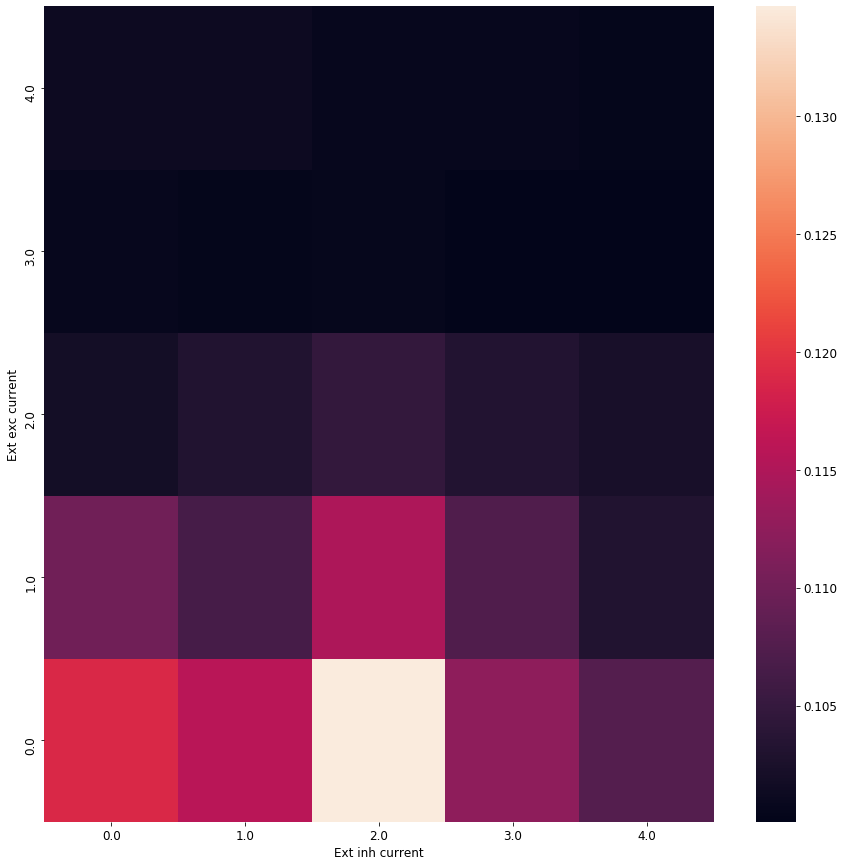

In [46]:
import seaborn as sns

x_axis_labels = np.around(c_range,2)
y_axis_labels = np.around(c_range,2)

fig, ax = plt.subplots(figsize=(15,15))

ax = sns.heatmap(diff, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
ax.invert_yaxis()
ax.set_ylabel('Ext exc current')
ax.set_xlabel('Ext inh current')

plt.savefig("current_convergence_sigma11.pdf")
plt.show()